In [263]:
import os
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns

path = '/home/mina-joojoo/Desktop/tool_wearing/'
dataset = pd.read_csv(path + 'all_data.csv')

In [264]:
dataset.describe()

,VB,C,tool,machine,torq_tot_mean,torq_tot_std,torq_tot_max,torq_tot_min,torq_tot_rms,torq_tot_skew,...,fy_max,fy_min,fy_rms,fy_skew,fz_mean,fz_std,fz_max,fz_min,fz_rms,fz_skew
count,6418.000000,6418.000000,6418.000000,6418.000000,1856.000000,1856.0,1856.000000,1856.000000,1856.000000,1856.0,...,4562.000000,4562.000000,4562.000000,4.562000e+03,4562.000000,4562.000000,4562.000000,4562.000000,4562.000000,4.562000e+03
mean,81.339981,2124.464475,4.968059,1.987847,221.661477,0.0,221.661477,221.661477,221.661477,0.0,...,253.683889,-776.977839,407.834715,-2.235255e+05,-64.875930,347.320740,990.113700,-1117.891620,556.186859,-3.270757e+06
std,30.149191,1304.602639,2.396248,0.752436,3.328708,0.0,3.328708,3.328708,3.328708,0.0,...,131.206304,656.414993,261.417056,9.973889e+06,346.016510,272.127107,1184.108680,565.818804,96.108770,1.474872e+07
min,3.000000,11.000000,1.000000,1.000000,212.786804,0.0,212.786804,212.786804,212.786804,0.0,...,-82.031250,-2341.796875,64.097275,-8.262330e+07,-581.101440,17.316572,-533.299988,-3574.953369,367.070618,-9.606671e+07
25%,58.000000,1045.250000,3.000000,1.000000,219.343689,0.0,219.343689,219.343689,219.343689,0.0,...,173.000000,-1239.013672,120.062674,-1.134785e+04,-470.480530,23.467924,-403.050003,-1544.435028,478.975281,-5.696668e+06
50%,79.000000,2048.000000,5.000000,2.000000,221.893982,0.0,221.893982,221.893982,221.893982,0.0,...,228.349998,-917.968750,461.578003,5.014717e+03,165.440636,461.539551,1485.454407,-1055.052307,542.611481,-6.857768e+03
75%,100.000000,3053.000000,7.000000,3.000000,223.989231,0.0,223.989231,223.989231,223.989231,0.0,...,312.500000,-43.500000,603.914062,2.903753e+06,220.269325,574.160126,1957.820129,-581.500000,616.635925,-1.882440e+03
max,160.000000,5181.000000,9.000000,3.000000,233.109909,0.0,233.109909,233.109909,233.109909,0.0,...,836.914062,14.600000,1005.733154,1.505806e+07,331.674774,940.730530,3785.176758,-485.100006,970.559509,1.343548e+08


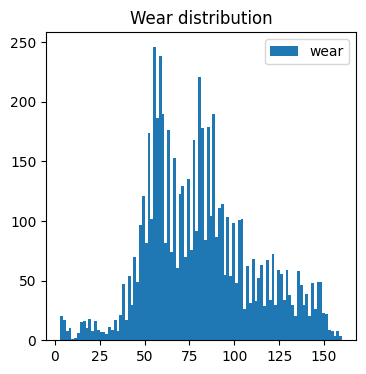

In [265]:
plt.figure(figsize=(4, 4))
plt.hist(dataset['VB'], bins = 100, label = 'wear')
plt.legend()
plt.title('Wear distribution')
plt.show()

VB distribution/ data is imbalanced

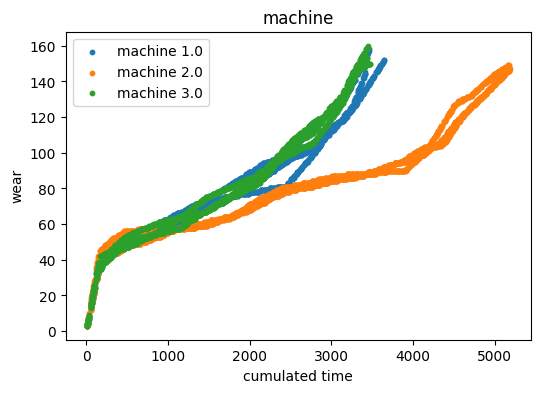

In [266]:
grouped = dataset.groupby('machine')
plt.figure(figsize = (6,4))
for machine, group in grouped:
    plt.scatter(group['C'],
                group['VB'], label = f'machine {machine}',
                s = 10)
plt.xlabel('cumulated time')
plt.ylabel('wear')
plt.legend()
plt.title('machine')
plt.show()

strong correlation, machine 2 is biased.

In [267]:
dataset['log_C'] = 0.1 + 0.5* np.log10(dataset['C'] + 0.000001)

In [268]:
dataset = pd.get_dummies(dataset, columns=["machine"], dtype=int)

dummy_cols = [col for col in dataset.columns if col.startswith("machine_")]

dataset[dummy_cols] = dataset[dummy_cols] * 0.98 + 0.01

In [269]:
dataset

,VB,C,tool,torq_tot_mean,torq_tot_std,torq_tot_max,torq_tot_min,torq_tot_rms,torq_tot_skew,pcx_mean,...,fz_mean,fz_std,fz_max,fz_min,fz_rms,fz_skew,log_C,machine_1.0,machine_2.0,machine_3.0
0,3.0,11.0,1.0,215.435974,0.0,215.435974,215.435974,215.435974,0.0,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,0.620696,0.99,0.01,0.01
1,3.0,15.0,1.0,215.752884,0.0,215.752884,215.752884,215.752884,0.0,-0.000012,...,NaN,NaN,NaN,NaN,NaN,NaN,0.688046,0.99,0.01,0.01
2,4.0,19.0,1.0,216.535309,0.0,216.535309,216.535309,216.535309,0.0,-0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,0.739377,0.99,0.01,0.01
3,5.0,23.0,1.0,215.211121,0.0,215.211121,215.211121,215.211121,0.0,-0.000009,...,NaN,NaN,NaN,NaN,NaN,NaN,0.780864,0.99,0.01,0.01
4,6.0,27.0,1.0,216.307037,0.0,216.307037,216.307037,216.307037,0.0,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,0.815682,0.99,0.01,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,158.0,3434.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000007,...,-528.078796,35.709236,-428.600006,-639.299988,529.284790,-12581.253906,1.867900,0.01,0.01,0.99
6414,159.0,3438.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000006,...,-526.252930,35.561707,-434.700012,-632.900024,527.453125,-11980.217773,1.868153,0.01,0.01,0.99
6415,159.0,3441.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000005,...,-526.485168,34.931442,-407.799988,-632.900024,527.642700,-11165.744141,1.868342,0.01,0.01,0.99
6416,159.0,3445.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000003,...,-525.807129,35.815331,-422.200012,-637.000000,527.025513,-11150.387695,1.868595,0.01,0.01,0.99


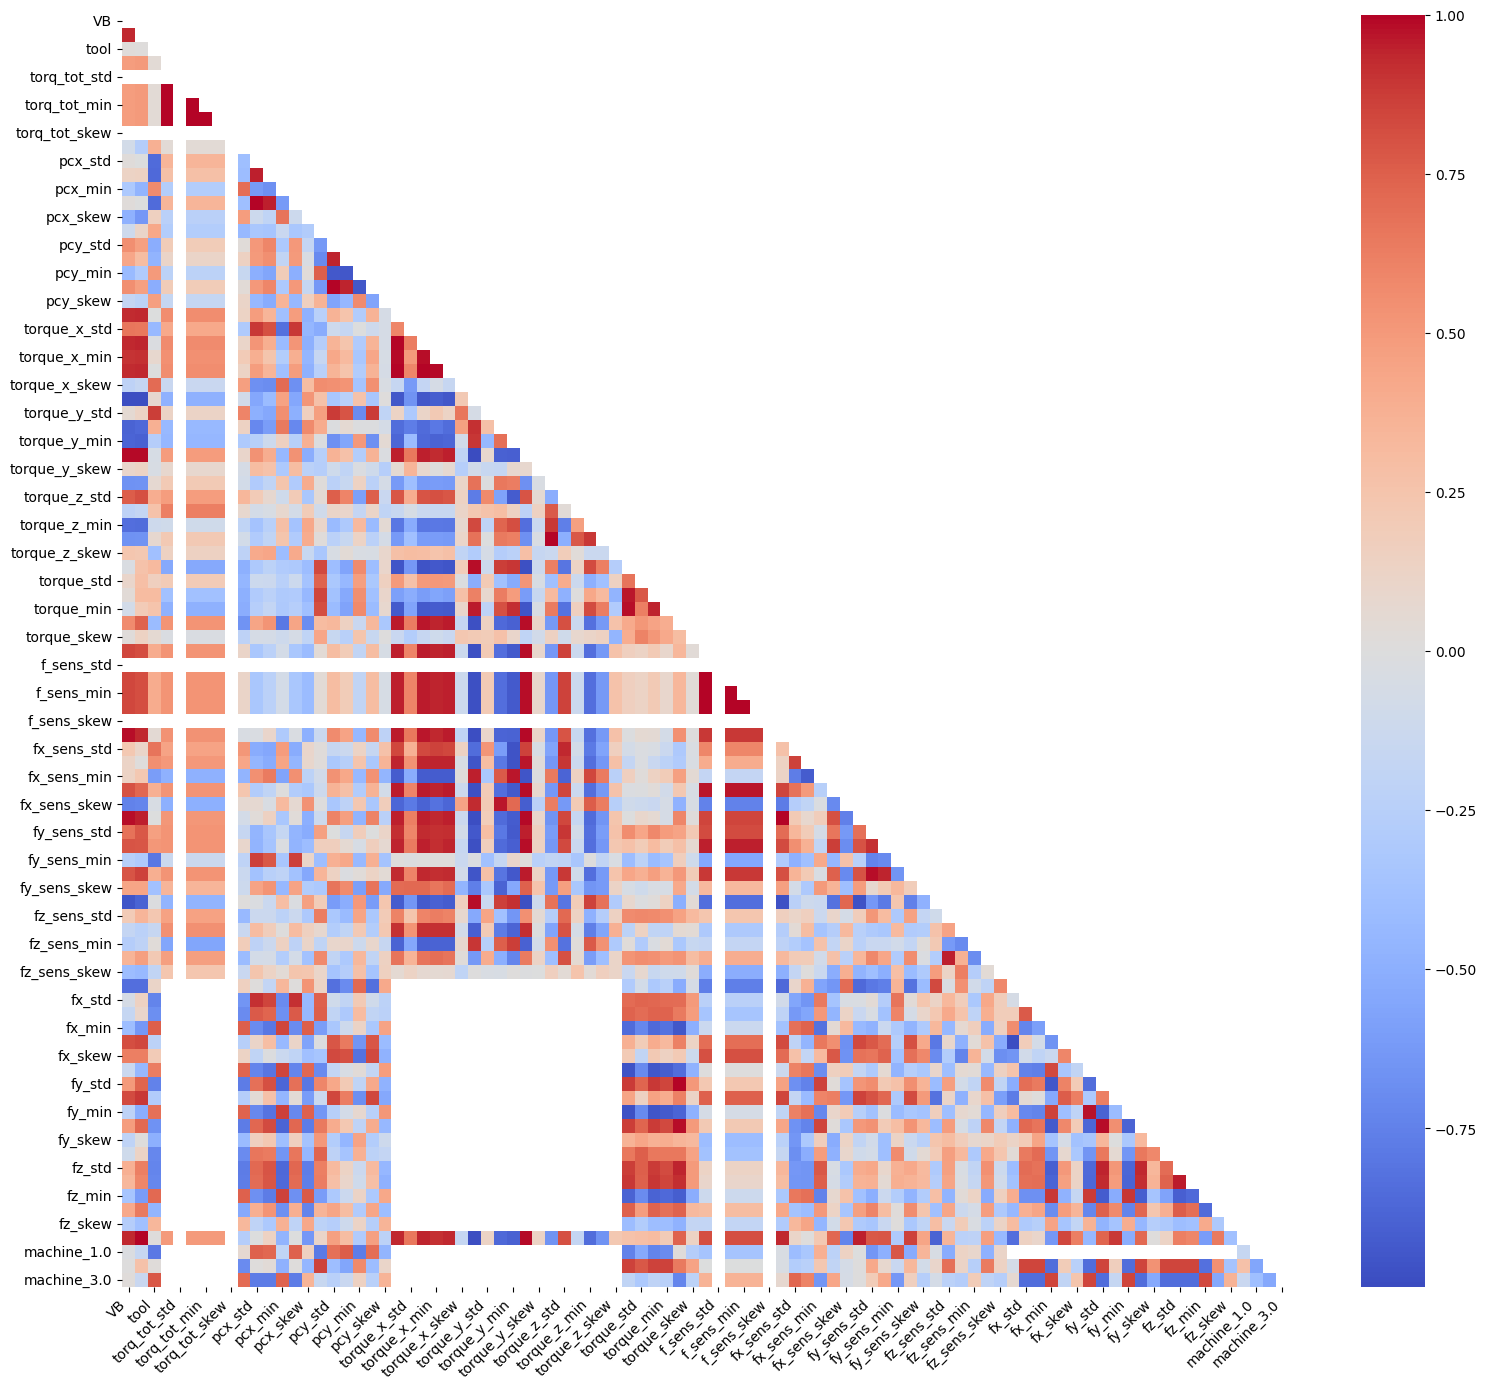

In [270]:
mask = np.triu(np.ones_like(dataset.corr(method="spearman"), dtype=bool))

plt.figure(figsize=(16, 14))
sns.heatmap(
    dataset.corr(method="spearman"),
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
)

plt.xticks(rotation=45, ha='right')  
plt.yticks(rotation=0)           
plt.tight_layout()               
plt.show()

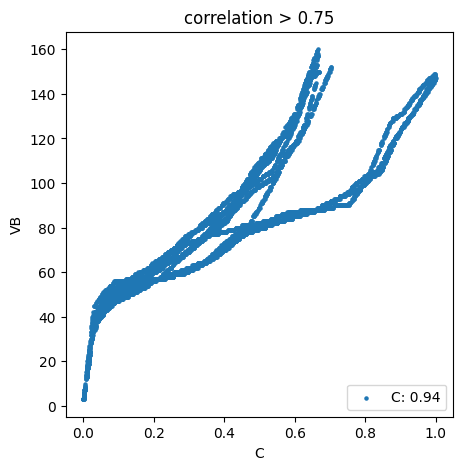

/home/mina-joojoo/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


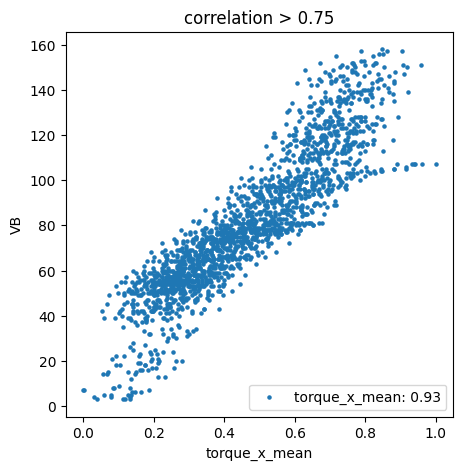

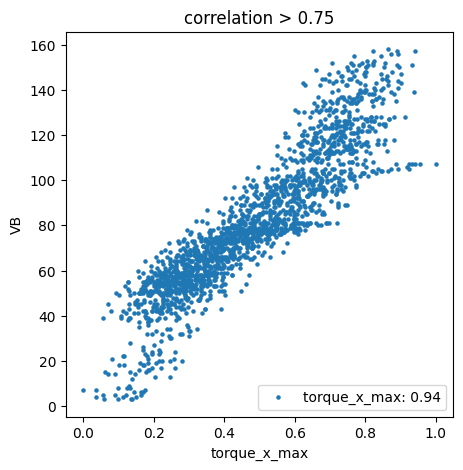

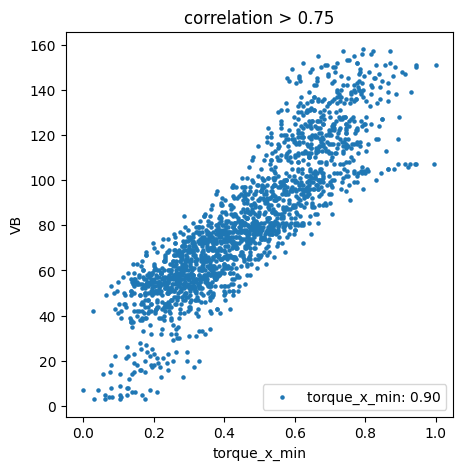

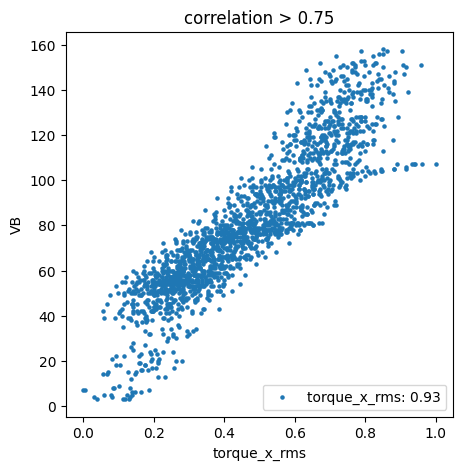

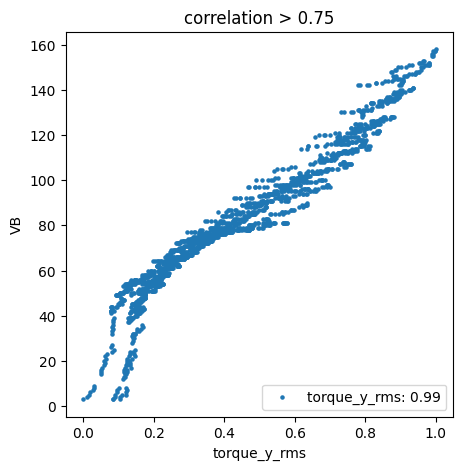

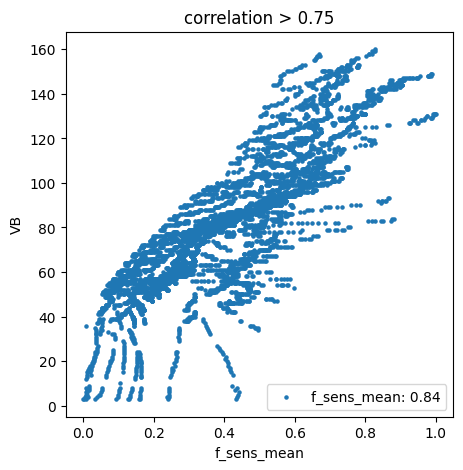

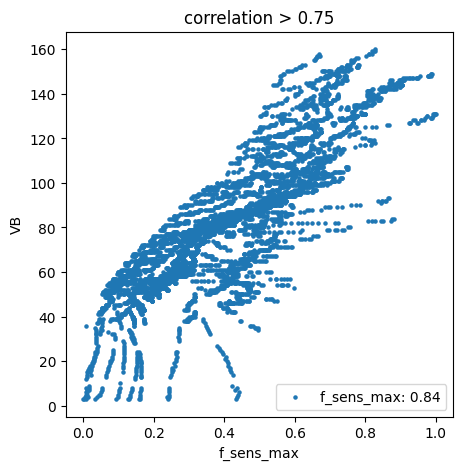

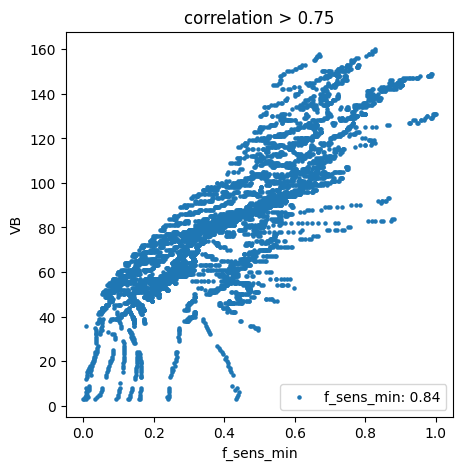

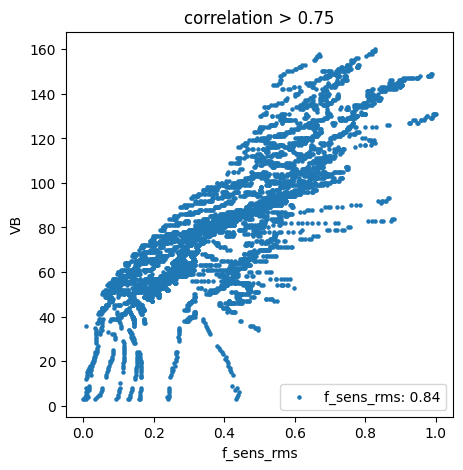

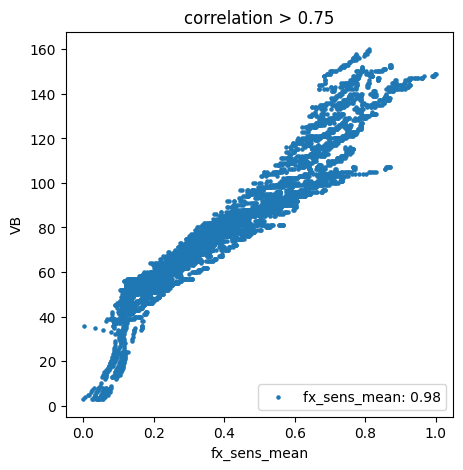

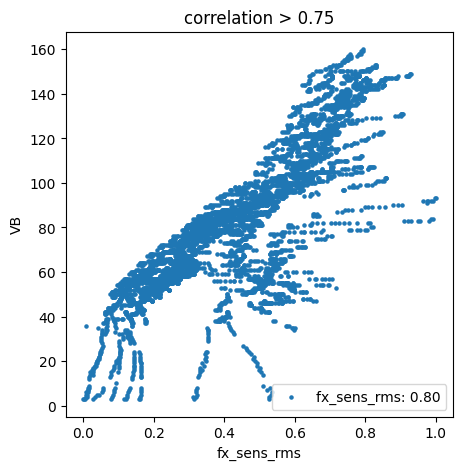

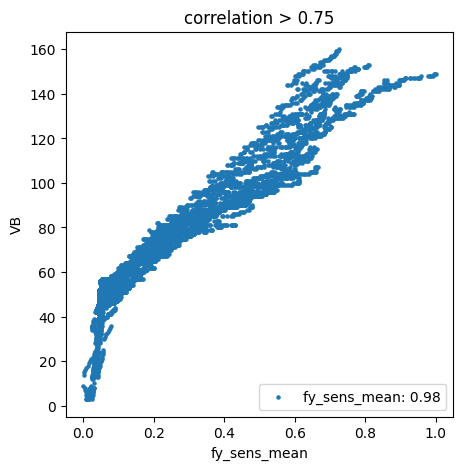

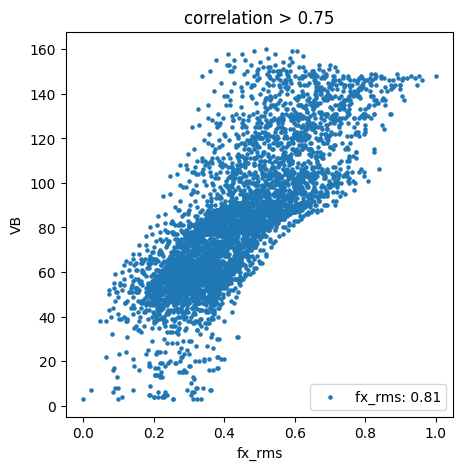

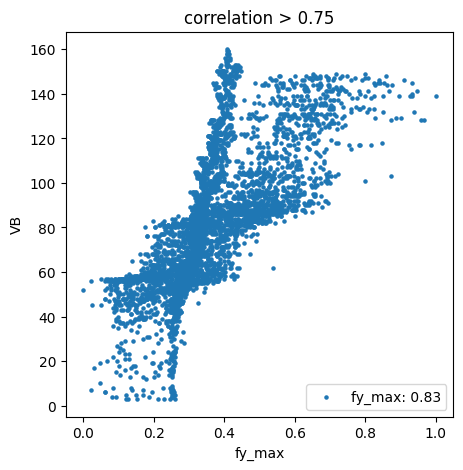

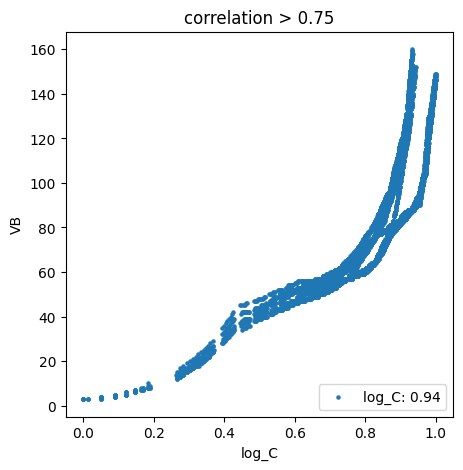

In [275]:
for c in dataset.columns.drop('VB'):
    corr = dataset['VB'].corr(dataset[c], method="spearman")
    if corr > 0.8:
        plt.figure(figsize=(5,5))   
        dataset[c] = dataset[c].apply(lambda x: (x - dataset[c].min()) / (dataset[c].max() ))
        plt.scatter(dataset[c], dataset['VB'], label = f'{c}: {corr:.2f}', s = 5)
        plt.legend(loc= 'lower right')
        plt.xlabel(c)
        plt.ylabel('VB')
        plt.title('correlation > 0.75')
        plt.show()

In [277]:
correlations = dataset.corr(method="spearman")['VB'].drop('VB')
high_corr_features = correlations[abs(correlations) > 0.7].index.tolist()
correlated_dataset = dataset[['VB', 'machine_1.0',	'machine_2.0',	'machine_3.0', 'tool'] + high_corr_features]
# Or PCA

In [278]:
X = correlated_dataset.drop('VB', axis=1)
y = correlated_dataset['VB']

<Axes: >

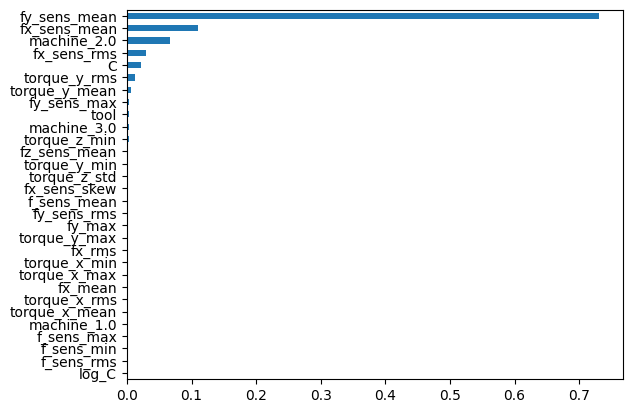

In [279]:

from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X, y)

import pandas as pd
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind="barh")


In [ ]:
sns.boxplot(x="machine", y="fy_sens_mean", data=correlated_dataset)

In [255]:

# from scipy.fft import fft

# def extract_freq_features(x):
#     X = np.abs(fft(x))
    
#     return {
#         "energy": np.sum(X**2),
#         "peak_freq": np.argmax(X)
#     }


In [280]:
correlated_dataset

,VB,machine_1.0,machine_2.0,machine_3.0,tool,C,torque_x_mean,torque_x_max,torque_x_min,torque_x_rms,...,fx_sens_rms,fx_sens_skew,fy_sens_mean,fy_sens_max,fy_sens_rms,fz_sens_mean,fx_mean,fx_rms,fy_max,log_C
0,3.0,0.99,0.01,0.01,1.0,0.000000,0.113359,0.097848,0.060797,0.113217,...,0.000000,1.145714e+05,0.007965,74.044540,41.504997,23.779776,NaN,NaN,NaN,0.000000
1,3.0,0.99,0.01,0.01,1.0,0.000774,0.118073,0.136987,0.104822,0.118800,...,0.004217,1.050379e+05,0.008839,74.929250,41.136345,23.613913,NaN,NaN,NaN,0.050392
2,4.0,0.99,0.01,0.01,1.0,0.001547,0.132263,0.148728,0.106918,0.132783,...,0.007958,8.546472e+04,0.011123,76.120964,40.705536,23.266512,NaN,NaN,NaN,0.088799
3,5.0,0.99,0.01,0.01,1.0,0.002321,0.077424,0.090020,0.060797,0.078028,...,0.010765,8.238866e+04,0.013739,82.683426,40.455530,23.055359,NaN,NaN,NaN,0.119840
4,6.0,0.99,0.01,0.01,1.0,0.003095,0.146385,0.142857,0.146751,0.146683,...,0.012686,7.927416e+04,0.016059,80.546616,40.773724,22.706730,NaN,NaN,NaN,0.145892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,158.0,0.01,0.01,0.99,9.0,0.662089,NaN,NaN,NaN,NaN,...,0.788777,-1.040985e+07,0.717210,878.048460,333.116200,-44.843910,-369.502136,0.411767,0.408763,0.933179
6414,159.0,0.01,0.01,0.99,9.0,0.662863,NaN,NaN,NaN,NaN,...,0.789091,-1.046673e+07,0.717495,890.069150,332.927730,-43.836490,-412.305511,0.483559,0.407784,0.933368
6415,159.0,0.01,0.01,0.99,9.0,0.663443,NaN,NaN,NaN,NaN,...,0.791689,-1.040608e+07,0.719864,875.783500,335.005250,-43.907974,-477.872040,0.593544,0.410069,0.933510
6416,159.0,0.01,0.01,0.99,9.0,0.664217,NaN,NaN,NaN,NaN,...,0.794456,-1.032460e+07,0.724149,905.257400,335.173070,-44.326687,-485.143860,0.605770,0.410940,0.933699


In [281]:
cols_to_normalize = [col for col in correlated_dataset.columns if col not in ['machine', 'tool']]


dataset_normalized = correlated_dataset.copy()

for col in cols_to_normalize:
    min_val = correlated_dataset[col].min()  # NaN are ignored by default
    max_val = correlated_dataset[col].max()
    
    if max_val != min_val:  # Avoid division by zero
        dataset_normalized[col] = (correlated_dataset[col] - min_val) / (max_val - min_val)
    else:
        # If all values are the same, set to 0.5 or keep as is
        pass

In [282]:
dataset_normalized

,VB,machine_1.0,machine_2.0,machine_3.0,tool,C,torque_x_mean,torque_x_max,torque_x_min,torque_x_rms,...,fx_sens_rms,fx_sens_skew,fy_sens_mean,fy_sens_max,fy_sens_rms,fz_sens_mean,fx_mean,fx_rms,fy_max,log_C
0,0.000000,1.0,0.0,0.0,1.0,0.000000,0.113359,0.097848,0.060797,0.113217,...,0.000000,0.564510,0.007965,0.000000,0.011185,0.969655,NaN,NaN,NaN,0.000000
1,0.000000,1.0,0.0,0.0,1.0,0.000774,0.118073,0.136987,0.104822,0.118800,...,0.004217,0.564362,0.008839,0.000755,0.010296,0.967939,NaN,NaN,NaN,0.050392
2,0.006369,1.0,0.0,0.0,1.0,0.001547,0.132263,0.148728,0.106918,0.132783,...,0.007958,0.564056,0.011123,0.001772,0.009257,0.964344,NaN,NaN,NaN,0.088799
3,0.012739,1.0,0.0,0.0,1.0,0.002321,0.077424,0.090020,0.060797,0.078028,...,0.010765,0.564008,0.013739,0.007374,0.008654,0.962159,NaN,NaN,NaN,0.119840
4,0.019108,1.0,0.0,0.0,1.0,0.003095,0.146385,0.142857,0.146751,0.146683,...,0.012686,0.563959,0.016059,0.005550,0.009421,0.958551,NaN,NaN,NaN,0.145892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,0.987261,0.0,0.0,1.0,9.0,0.662089,NaN,NaN,NaN,NaN,...,0.788777,0.400178,0.717210,0.686303,0.714535,0.259497,0.564412,0.411767,0.408763,0.933179
6414,0.993631,0.0,0.0,1.0,9.0,0.662863,NaN,NaN,NaN,NaN,...,0.789091,0.399290,0.717495,0.696564,0.714081,0.269923,0.488684,0.483559,0.407784,0.933368
6415,0.993631,0.0,0.0,1.0,9.0,0.663443,NaN,NaN,NaN,NaN,...,0.791689,0.400237,0.719864,0.684370,0.719091,0.269183,0.372683,0.593544,0.410069,0.933510
6416,0.993631,0.0,0.0,1.0,9.0,0.664217,NaN,NaN,NaN,NaN,...,0.794456,0.401509,0.724149,0.709529,0.719496,0.264850,0.359817,0.605770,0.410940,0.933699


In [283]:
dataset_normalized.to_csv('correlated_dataset.csv', index=False)